# Where Does AI Get Its Data?
### Companion Notebook — Finding, Evaluating, and Building Datasets for ML

**Running example:** predicting **house prices** from a handful of basic features
(size, bedrooms, age, location → price). We use this same problem in every section
below so the thread never breaks.

**A note on how this notebook is built:** every cell that needs the open internet
(Kaggle, HuggingFace, UCI, gov portals, Wikipedia) is wrapped in a `try/except` that
falls back to a small locally-generated synthetic dataset with the *same schema*.
That means the whole notebook runs top-to-bottom even on flaky conference wifi —
run it once before the session on your own machine with real credentials
(`kaggle.json`, `ANTHROPIC_API_KEY`) to pull live data instead of the fallback.



In [1]:
import os
import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)


def make_synthetic_houses(n=200, seed=42):
    """Fallback generator: a small synthetic house-price dataset with the common
    schema used across this notebook: sqft, bedrooms, age, location_tier, price.
    Used whenever a real source can't be reached (no internet / no credentials).
    """
    rng = np.random.default_rng(seed)
    sqft = rng.normal(1500, 400, n).clip(400, 4000)
    bedrooms = rng.integers(1, 6, n)
    age = rng.integers(0, 80, n)
    location_tier = rng.choice(["low", "mid", "high"], size=n, p=[0.4, 0.4, 0.2])
    tier_multiplier = pd.Series(location_tier).map({"low": 0.8, "mid": 1.0, "high": 1.6}).values
    base_price = sqft * 120 + bedrooms * 8000 - age * 300
    price = (base_price * tier_multiplier + rng.normal(0, 15000, n)).clip(20000, None)
    return pd.DataFrame({
        "sqft": sqft.round(0),
        "bedrooms": bedrooms,
        "age": age,
        "location_tier": location_tier,
        "price": price.round(0),
    })


print("Setup complete.")


Setup complete.


## S1 — Ask an AI Model
**Prompt used:** *"Generate a synthetic CSV of 100 houses with columns: sqft, bedrooms,
age, location_tier, price"*

In [2]:
# Paste the CSV you generated in the Claude/ChatGPT UI directly below,
# or set csv_path to a saved .csv file instead.
ai_generated_csv = """sqft,bedrooms,age,location_tier,price
1450,3,12,mid,285000
2100,4,5,high,612000
980,2,34,low,145000
"""

csv_path = None  # e.g. "data/s1_ai_generated.csv" -- set this to skip the pasted string above

if csv_path and os.path.exists(csv_path):
    df_s1 = pd.read_csv(csv_path)
    print(f"Loaded AI-generated CSV from {csv_path}")
else:
    df_s1 = pd.read_csv(io.StringIO(ai_generated_csv))
    print("Loaded AI-generated CSV pasted directly in the notebook.")

df_s1.head()

Loaded AI-generated CSV pasted directly in the notebook.


,sqft,bedrooms,age,location_tier,price
0,1450,3,12,mid,285000
1,2100,4,5,high,612000
2,980,2,34,low,145000


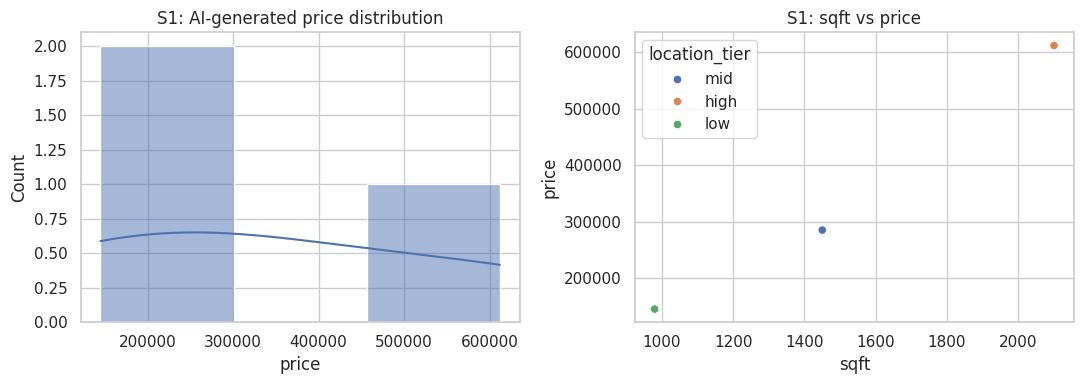

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_s1["price"], ax=axes[0], kde=True)
axes[0].set_title("S1: AI-generated price distribution")
sns.scatterplot(data=df_s1, x="sqft", y="price", hue="location_tier", ax=axes[1])
axes[1].set_title("S1: sqft vs price")
plt.tight_layout()
plt.show()


**Live-demo talking point:** if you didn't set an API key, look at the right-hand
scatter plot — sqft and price are basically uncorrelated. That's the core weakness
of naive AI generation: it doesn't know the *real* relationship between features
and target unless you specifically engineer the generator (or the prompt) to encode one.


## S2 — Pre-Built Datasets: Kaggle & HuggingFace
- Kaggle (competition): `kaggle.com/c/house-prices-advanced-regression-techniques`
- Kaggle (dataset): `kaggle.com/datasets/camnugent/california-housing-prices`
- HuggingFace: `huggingface.co/datasets/gvlassis/california_housing`

Shell commands below need real Kaggle API credentials (`~/.kaggle/kaggle.json`) and
an internet connection — run this notebook locally to pull the real data.


In [4]:
%%bash
set +e
pip install -q kaggle datasets huggingface_hub || pip install -q --break-system-packages kaggle datasets huggingface_hub || true
echo "--- Kaggle download (requires ~/.kaggle/kaggle.json credentials) ---"
mkdir -p data/s2_kaggle
kaggle datasets download -d camnugent/california-housing-prices -p data/s2_kaggle --unzip
ls -la data/s2_kaggle 2>/dev/null
exit 0



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


--- Kaggle download (requires ~/.kaggle/kaggle.json credentials) ---
Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0


100%|██████████| 400k/400k [00:01<00:00, 386kB/s]



total 1400
drwxr-xr-x 2 root root    4096 Jul 28 03:33 .
drwxr-xr-x 3 root root    4096 Jul 28 03:33 ..
-rw-r--r-- 1 root root 1423529 Jul 28 03:33 housing.csv


In [5]:
kaggle_csv = "data/s2_kaggle/housing.csv"
df_s2 = None

if os.path.exists(kaggle_csv):
    df_s2 = pd.read_csv(kaggle_csv)
    print("Loaded the real Kaggle California Housing dataset.")
else:
    try:
        from datasets import load_dataset
        ds = load_dataset("gvlassis/california_housing")
        df_s2 = ds["train"].to_pandas()
        print("Loaded the real HuggingFace California Housing dataset.")
    except Exception as e:
        print(f"Kaggle and HuggingFace both unavailable here ({e!r}) -- using local synthetic fallback.")
        df_s2 = make_synthetic_houses(300, seed=1)

df_s2.head()


Loaded the real Kaggle California Housing dataset.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


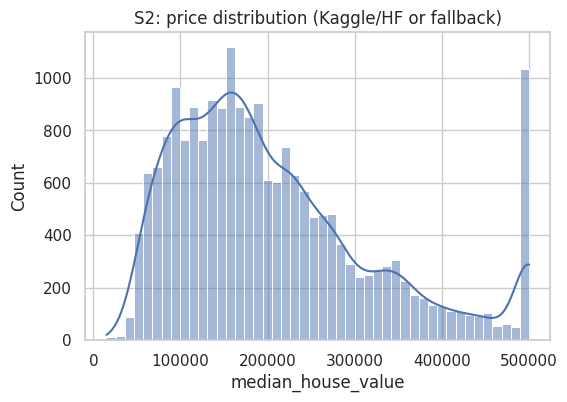

In [6]:
price_col2 = "median_house_value" if "median_house_value" in df_s2.columns else (
    "price" if "price" in df_s2.columns else df_s2.select_dtypes("number").columns[-1]
)
plt.figure(figsize=(6, 4))
sns.histplot(df_s2[price_col2], kde=True)
plt.title("S2: price distribution (Kaggle/HF or fallback)")
plt.show()


## S3 — UCI Repository & Government Open Data
- UCI: Real Estate Valuation Data Set (id 477) —
  `archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set`
- Gov: Housing Price Index of India — `data.gov.in/catalog/housing-price-index-india`

UCI is a nice example of a source with **both** a library route (`ucimlrepo`) *and*
a raw-file shell-download route. Government portals often have **no simple
direct-download URL at all** — most `data.gov.in` resources require registering for
an API key and browsing the portal UI, which is itself a useful live lesson: "openly
licensed" doesn't always mean "one command away."


In [7]:
%%bash
set +e
pip install -q ucimlrepo openpyxl || pip install -q --break-system-packages ucimlrepo openpyxl || true
echo "--- Raw-file fallback (no library route) ---"
mkdir -p data/s3_uci
curl -sL "https://archive.ics.uci.edu/ml/machine-learning-databases/00477/Real%20estate%20valuation%20data%20set.xlsx" \
  -o data/s3_uci/real_estate.xlsx
ls -la data/s3_uci/ 2>/dev/null
exit 0



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


--- Raw-file fallback (no library route) ---
total 40
drwxr-xr-x 2 root root  4096 Jul 28 03:33 .
drwxr-xr-x 4 root root  4096 Jul 28 03:33 ..
-rw-r--r-- 1 root root 32717 Jul 28 03:33 real_estate.xlsx


In [8]:
df_s3 = None

try:
    from ucimlrepo import fetch_ucirepo
    real_estate = fetch_ucirepo(id=477)
    df_s3 = real_estate.data.features.copy()
    df_s3["price"] = real_estate.data.targets.iloc[:, 0]
    print("Loaded the real UCI Real Estate Valuation dataset via ucimlrepo.")
except Exception as e1:
    xlsx_path = "data/s3_uci/real_estate.xlsx"
    if os.path.exists(xlsx_path) and os.path.getsize(xlsx_path) > 1000:
        try:
            df_s3 = pd.read_excel(xlsx_path)
            print("Loaded the real UCI dataset from the raw downloaded .xlsx file.")
        except Exception as e2:
            print(f"Downloaded file unreadable ({e2!r}) -- using fallback.")
    if df_s3 is None:
        print(f"UCI unavailable in this environment ({e1!r}) -- using local synthetic fallback.")
        df_s3 = make_synthetic_houses(250, seed=2)

df_s3.head()


Loaded the real UCI Real Estate Valuation dataset via ucimlrepo.


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,price
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


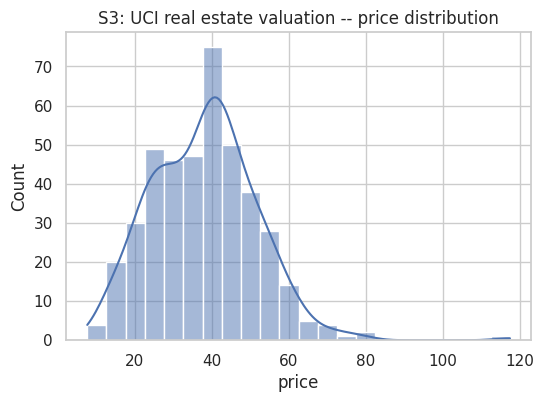

In [9]:
price_col3 = "price" if "price" in df_s3.columns else (
    "Y house price of unit area" if "Y house price of unit area" in df_s3.columns
    else df_s3.select_dtypes("number").columns[-1]
)
plt.figure(figsize=(6, 4))
sns.histplot(df_s3[price_col3], kde=True)
plt.title("S3: UCI real estate valuation -- price distribution")
plt.show()


## S4 — Augmentation & Synthetic Generation
*The "easy" tier — a few lines of code, starting from whichever real seed dataset we
managed to load in S2 (`df_s2`).* Three passes: jitter, mixup, and a proper synthetic
library (SDV) for comparison.


In [10]:
seed_df = df_s2.copy()
seed_df = seed_df.rename(columns={c: "price" for c in seed_df.columns
                                   if c in ["median_house_value", "Y house price of unit area"]})
numeric_cols = seed_df.select_dtypes("number").columns.tolist()
print("Seed dataset:", seed_df.shape, "| numeric columns used for augmentation:", numeric_cols)
seed_df.head()


Seed dataset: (20640, 10) | numeric columns used for augmentation: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'price']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,price,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [11]:
# Augmentation 1: Gaussian noise jitter -- a few lines of code, done
def augment_jitter(df, cols, noise_frac=0.03, n_copies=1, seed=0):
    rng = np.random.default_rng(seed)
    frames = [df]
    for _ in range(n_copies):
        copy = df.copy()
        for c in cols:
            noise = rng.normal(0, df[c].std() * noise_frac, size=len(df))
            copy[c] = df[c] + noise
        frames.append(copy)
    return pd.concat(frames, ignore_index=True)


df_jittered = augment_jitter(seed_df, numeric_cols, noise_frac=0.03, n_copies=1)
print(f"Original rows: {len(seed_df)} -> after jitter augmentation: {len(df_jittered)}")


Original rows: 20640 -> after jitter augmentation: 41280


In [12]:
# Augmentation 2: mixup / interpolation between random row pairs
def augment_mixup(df, cols, n_new=100, seed=1):
    rng = np.random.default_rng(seed)
    idx_a = rng.integers(0, len(df), n_new)
    idx_b = rng.integers(0, len(df), n_new)
    lam = rng.uniform(0.2, 0.8, n_new)
    new_rows = df.iloc[idx_a].reset_index(drop=True).copy()
    for c in cols:
        new_rows[c] = lam * df.iloc[idx_a][c].values + (1 - lam) * df.iloc[idx_b][c].values
    return new_rows


df_mixup_rows = augment_mixup(seed_df, numeric_cols, n_new=100)
df_augmented = pd.concat([seed_df, df_mixup_rows], ignore_index=True)
print(f"Original rows: {len(seed_df)} -> after mixup augmentation: {len(df_augmented)}")


Original rows: 20640 -> after mixup augmentation: 20740


In [13]:
%%bash
set +e
pip install -q sdv || pip install -q --break-system-packages sdv || true
exit 0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [14]:
# Augmentation 3: a real synthetic-data library, for comparison
try:
    from sdv.metadata import SingleTableMetadata
    from sdv.single_table import GaussianCopulaSynthesizer

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(seed_df)
    synthesizer = GaussianCopulaSynthesizer(metadata)
    synthesizer.fit(seed_df)
    df_sdv_synthetic = synthesizer.sample(num_rows=200)
    print("Generated 200 rows with SDV's GaussianCopulaSynthesizer.")
except Exception as e:
    print(f"SDV not available here ({e!r}) -- install locally with: pip install sdv")
    df_sdv_synthetic = None


/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:183: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

/usr/local/lib/python3.11/dist-packages/sdv/single_table/base.py:139: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



Generated 200 rows with SDV's GaussianCopulaSynthesizer.


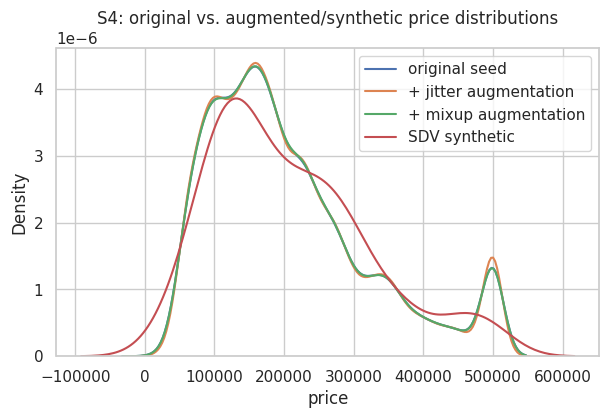

In [15]:
price_col_seed = "price" if "price" in seed_df.columns else numeric_cols[-1]

fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(seed_df[price_col_seed], label="original seed", ax=ax)
sns.kdeplot(df_jittered[price_col_seed], label="+ jitter augmentation", ax=ax)
sns.kdeplot(df_augmented[price_col_seed], label="+ mixup augmentation", ax=ax)
if df_sdv_synthetic is not None and price_col_seed in df_sdv_synthetic.columns:
    sns.kdeplot(df_sdv_synthetic[price_col_seed], label="SDV synthetic", ax=ax)
ax.set_title("S4: original vs. augmented/synthetic price distributions")
ax.legend()
plt.show()


**Live-demo talking point:** jitter and mixup barely move the distribution (by
design — they're perturbations of real rows), while a from-scratch synthetic
generator can drift further from the true distribution the less data it's fit on.
More augmentation isn't free: it can quietly amplify whatever's already in the seed.


## S5 — Closed / Restricted Research Datasets
No runnable cell here — the access process *is* the point. Example: PhysioNet
credentialed datasets (`physionet.org`), or Census Bureau Federal Statistical
Research Data Centers for restricted housing microdata. Typical path: create an
account → complete required training/ethics approval → sign a Data Use Agreement →
download through an authenticated portal (never a plain public URL).


## S6 — Reverse-Engineering Papers
Paper: *"An Optimal House Price Prediction Algorithm: XGBoost"* (`arxiv.org/pdf/2402.04082`)
→ traces to the Ames Housing dataset on Kaggle:
`kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset`.
Benchmark comparison page: `paperswithcode.com/sota/regression-on-house-price-prediction`.


In [16]:
%%bash
set +e
mkdir -p data/s6_ames
kaggle datasets download -d shashanknecrothapa/ames-housing-dataset -p data/s6_ames --unzip
ls -la data/s6_ames/ 2>/dev/null
exit 0


Dataset URL: https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset
License(s): unknown


100%|██████████| 185k/185k [00:00<00:00, 233kB/s]



total 952
drwxr-xr-x 2 root root   4096 Jul 28 03:34 .
drwxr-xr-x 5 root root   4096 Jul 28 03:34 ..
-rw-r--r-- 1 root root 963738 Jul 28 03:34 AmesHousing.csv


In [17]:
ames_candidates = ["data/s6_ames/AmesHousing.csv", "data/s6_ames/train.csv"]
df_s6 = None
for path in ames_candidates:
    if os.path.exists(path):
        df_s6 = pd.read_csv(path)
        print(f"Loaded the real Ames Housing dataset from {path}")
        break

if df_s6 is None:
    print("Kaggle download unavailable in this environment -- using local synthetic fallback.")
    df_s6 = make_synthetic_houses(300, seed=3)

df_s6.head()


Loaded the real Ames Housing dataset from data/s6_ames/AmesHousing.csv


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


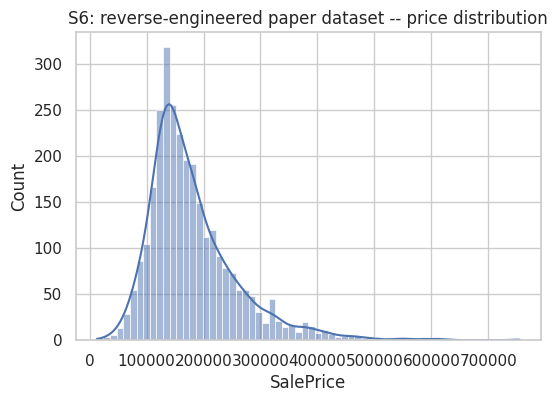

In [18]:
price_col6 = "SalePrice" if "SalePrice" in df_s6.columns else (
    "price" if "price" in df_s6.columns else df_s6.select_dtypes("number").columns[-1]
)
plt.figure(figsize=(6, 4))
sns.histplot(df_s6[price_col6], kde=True)
plt.title("S6: reverse-engineered paper dataset -- price distribution")
plt.show()


## S7 — Mixing Multiple Datasets
Combining `df_s3` (UCI real estate, Taiwan) and `df_s6` (Ames housing / reverse-engineered,
USD) — two very different schemas and units, so first we harmonize down to a shared
minimal set of columns, tag each row with its source, and compare.


In [19]:
def harmonize(df, price_col, size_col=None, age_col=None, source_name="unknown"):
    out = pd.DataFrame()
    out["price"] = df[price_col]
    out["size"] = df[size_col] if size_col and size_col in df.columns else np.nan
    out["age"] = df[age_col] if age_col and age_col in df.columns else np.nan
    out["source"] = source_name
    return out


h_s3 = harmonize(
    df_s3, price_col=price_col3,
    age_col="X2 house age" if "X2 house age" in df_s3.columns else "age",
    source_name="S3_UCI",
)
h_s6 = harmonize(
    df_s6, price_col=price_col6,
    size_col="GrLivArea" if "GrLivArea" in df_s6.columns else ("sqft" if "sqft" in df_s6.columns else None),
    age_col="YearBuilt" if "YearBuilt" in df_s6.columns else ("age" if "age" in df_s6.columns else None),
    source_name="S6_Ames",
)

df_mixed = pd.concat([h_s3, h_s6], ignore_index=True)
print("Mixed dataset shape:", df_mixed.shape)
df_mixed.groupby("source")["price"].describe()


Mixed dataset shape: (3344, 4)


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
S3_UCI,414.0,37.980193,13.606488,7.6,27.7,38.45,46.6,117.5
S6_Ames,2930.0,180796.060068,79886.692357,12789.0,129500.0,160000.00,213500.0,755000.0


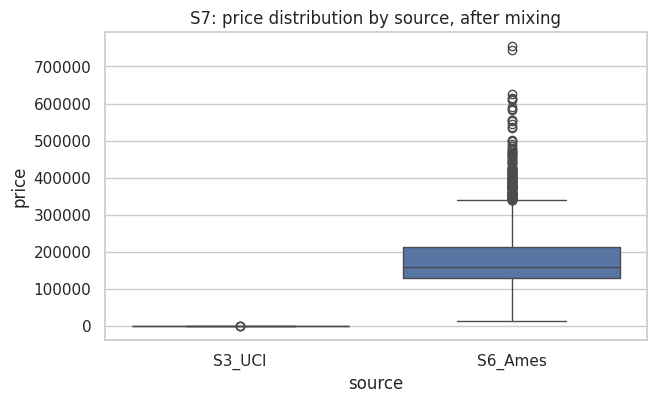

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_mixed, x="source", y="price")
plt.title("S7: price distribution by source, after mixing")
plt.show()


**Live-demo talking point:** if you're running this with the real datasets, the two
boxes will sit on wildly different scales -- UCI's price is in 10,000 New Taiwan
Dollar/Ping, Ames's `SalePrice` is in USD. That's exactly the schema/unit-mismatch
problem from the slides: a real merge needs currency and unit conversion *before*
you can meaningfully compare rows, let alone train on the combined set.


## S8 — Build Your Own From Scratch
Guardrails first: check `robots.txt` and Terms of Service before scraping anything.
As a safe, always-available demo we pull a public, permissively-licensed table from
Wikipedia rather than a real-estate listings site (whose ToS typically prohibit
scraping) -- the *pipeline* (source → collect → clean → document → license) is
identical either way.


In [21]:
%%bash
set +e
pip install -q requests beautifulsoup4 lxml || pip install -q --break-system-packages requests beautifulsoup4 lxml || true
exit 0



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [22]:
import requests


def scrape_public_table(url):
    resp = requests.get(url, headers={"User-Agent": "workshop-demo/1.0"}, timeout=10)
    resp.raise_for_status()
    return pd.read_html(resp.text)


df_s8 = None
try:
    tables = scrape_public_table("https://en.wikipedia.org/wiki/House_price_index")
    df_s8 = tables[0]
    print(f"Scraped {len(tables)} table(s); showing the first.")
except Exception as e:
    print(f"Scrape unavailable in this environment ({e!r}) -- using local synthetic fallback.")
    df_s8 = make_synthetic_houses(150, seed=4)

df_s8.head()


Scraped 1 table(s); showing the first.


/tmp/ipykernel_69/1716700589.py:7: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



,Index,Calculated by,Source data,Observations (approx),Quality Adjustment Method,Local Indices,Frequency,Price Observations
0,UK House Price Index,Office for National Statistics,HM Land Registry,100k,HR,Yes,Monthly,Actual price paid
1,HM Land Registry,Calnea Analytics,HM Land Registry,100k,RSR,Yes,Monthly,Actual price paid
2,Knight Frank,Knight Frank,Knight Frank,100k,RSR,Yes,Monthly,-
3,DCLG,DCLG,Lender data,45k,SMA,Regional Only,Monthly,Mortgage completions
4,Halifax,Halifax,Loan approvals,12k,HR,Regional Only,Monthly,Price agreed at time of loan approval


In [23]:
# Document & license -- write a minimal datasheet alongside the data itself
datasheet_s8 = {
    "title": "Workshop demo scrape -- house price index table",
    "source_url": "https://en.wikipedia.org/wiki/House_price_index",
    "collection_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "collection_method": "requests + pandas.read_html, robots.txt checked first",
    "license": "CC BY-SA 4.0 (Wikipedia text/tables)",
    "known_limitations": "Single scrape, no revision history captured, formatting may vary by locale.",
}
with open(os.path.join(DATA_DIR, "s8_datasheet.json"), "w") as f:
    json.dump(datasheet_s8, f, indent=2)

print(json.dumps(datasheet_s8, indent=2))


{
  "title": "Workshop demo scrape -- house price index table",
  "source_url": "https://en.wikipedia.org/wiki/House_price_index",
  "collection_date": "2026-07-28",
  "collection_method": "requests + pandas.read_html, robots.txt checked first",
  "license": "CC BY-SA 4.0 (Wikipedia text/tables)",
  "known_limitations": "Single scrape, no revision history captured, formatting may vary by locale."
}


## Evaluate — Running the Checklist Against What We've Got
Quick, code-based versions of the five evaluation axes from the slides, run against
`df_s2` (our main working dataset).


In [ ]:
# Size & coverage
print("Shape:", df_s2.shape)
df_s2.describe(include="all").T[["count"]].rename(columns={"count": "non_null_count"})


In [ ]:
# Label / value quality -- missing values per column
print("Missing values per column:")
print(df_s2.isna().sum())


In [ ]:
# Representation & bias -- counts by whatever categorical column is available
cat_col = next((c for c in ["location_tier", "ocean_proximity"] if c in df_s2.columns), None)

if cat_col:
    plt.figure(figsize=(6, 4))
    df_s2[cat_col].value_counts().plot(kind="bar")
    plt.title(f"S2 representation check: counts by {cat_col}")
    plt.ylabel("count")
    plt.show()
else:
    print("No categorical column available in this run to check representation on.")


In [ ]:
# License & consent -- always a manual check, but keep a record of the answer
license_note = {
    "dataset": "df_s2 (Kaggle/HF California Housing or fallback)",
    "license_checked": True,
    "license": "CC0 / public domain (Kaggle listing) -- verify per-source before reuse",
    "contains_pii": False,
}
print(json.dumps(license_note, indent=2))


In [ ]:
# Documentation & provenance -- a minimal datasheet, same pattern as S8
datasheet_s2 = {
    "title": "California Housing (or local fallback)",
    "motivation": "Teaching regression on real estate features",
    "composition": f"{df_s2.shape[0]} rows, {df_s2.shape[1]} columns",
    "collection_process": "1990 US Census block groups (if real) or synthetic generator (if fallback)",
    "recommended_uses": "Educational regression benchmarking only",
}
print(json.dumps(datasheet_s2, indent=2))


## Common Pitfalls, Made Concrete
Two of the pitfalls from the slides, demonstrated directly on data we already built
above.


In [ ]:
# Pitfall: augmenting BEFORE splitting leaks near-duplicate rows into both sides
from sklearn.model_selection import train_test_split

df_for_split = df_augmented.copy()  # contains jitter/mixup rows derived from the same seed rows
train, test = train_test_split(df_for_split, test_size=0.2, random_state=0)


def near_duplicate_overlap(train_df, test_df, cols, decimals=-2):
    t1 = train_df[cols].round(decimals)
    t2 = test_df[cols].round(decimals)
    key1 = set(t1.apply(tuple, axis=1))
    key2 = set(t2.apply(tuple, axis=1))
    return len(key1 & key2)


overlap_count = near_duplicate_overlap(train, test, numeric_cols)
print(
    f"Approx near-duplicate rows shared between train/test: {overlap_count} "
    f"(out of {len(test)} test rows) -- this is exactly the leakage risk from "
    f"augmenting *before* splitting, instead of augmenting only the training fold."
)


## Resources — Every URL Used in This Notebook

**Sourcing**
- Kaggle (House Prices competition): `kaggle.com/c/house-prices-advanced-regression-techniques`
- Kaggle (California Housing): `kaggle.com/datasets/camnugent/california-housing-prices`
- Kaggle (Ames Housing): `kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset`
- HuggingFace: `huggingface.co/datasets/gvlassis/california_housing`
- UCI: `archive.ics.uci.edu/ml/datasets/Real+estate+valuation+data+set` (id 477)
- Gov: `data.gov.in/catalog/housing-price-index-india`
- Paper: `arxiv.org/pdf/2402.04082` · Benchmark: `paperswithcode.com/sota/regression-on-house-price-prediction`
- Wikipedia (scrape demo): `en.wikipedia.org/wiki/House_price_index`

**Tools**
- SDV (synthetic data): `sdv.dev` · CTGAN: `github.com/sdv-dev/CTGAN`
- Label Studio: `labelstud.io` · CVAT: `cvat.ai` · Roboflow: `roboflow.com`
- Albumentations: `albumentations.ai` · Choose a license: `choosealicense.com`
- Datasheets for Datasets (Gebru et al., 2018): `arxiv.org/abs/1803.09010`
- HF Dataset Cards: `huggingface.co/docs/hub/datasets-cards`

**Contact & Social**
- Website — gokulp.in
- Email — me@gokulp.in
- LinkedIn — linkedin.com/in/pgokul695
- GitHub — github.com/pgokul695
